In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import layers, models
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import time
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from keras.callbacks import EarlyStopping,ReduceLROnPlateau
from matplotlib import pyplot as plt

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"keshrivishal21","key":"4c8bb86460f4dd386e694fd83bc26447"}'}

In [ ]:
!mkdir -p ~/.config/kaggle
!mv kaggle.json ~/.config/kaggle/
!chmod 600 ~/.config/kaggle/kaggle.json

In [ ]:
!kaggle competitions download -c state-farm-distracted-driver-detection

100% 4.00G/4.00G [00:37<00:00, 115MB/s]



In [ ]:
!unzip -q state-farm-distracted-driver-detection.zip -d data

In [ ]:
df = pd.read_csv("/content/data/driver_imgs_list.csv")
df.head()

,subject,classname,img
0,p002,c0,img_44733.jpg
1,p002,c0,img_72999.jpg
2,p002,c0,img_25094.jpg
3,p002,c0,img_69092.jpg
4,p002,c0,img_92629.jpg


In [ ]:
drivers = df['subject'].unique()
print("Total drivers:", len(drivers))

Total drivers: 26


In [ ]:
train_drivers, temp_drivers = train_test_split(
    drivers,
    test_size=0.4,
    random_state=42
)

val_drivers, test_drivers = train_test_split(
    temp_drivers,
    test_size=0.5,
    random_state=42
)

print("Train drivers:", len(train_drivers))
print("Val drivers:", len(val_drivers))
print("Test drivers:", len(test_drivers))

Train drivers: 15
Val drivers: 5
Test drivers: 6


In [ ]:
train_df = df[df['subject'].isin(train_drivers)]
val_df = df[df['subject'].isin(val_drivers)]
test_df = df[df['subject'].isin(test_drivers)]

print(train_df['subject'].nunique())
print(val_df['subject'].nunique())
print(test_df['subject'].nunique())

15
5
6


In [ ]:
base_path = "/content/data/imgs/train"

def add_image_path(df):
    return df.apply(
        lambda row: os.path.join(base_path, row['classname'], row['img']),
        axis=1
    )

train_paths = add_image_path(train_df)
val_paths = add_image_path(val_df)
test_paths = add_image_path(test_df)

train_labels = train_df['classname']
val_labels = val_df['classname']
test_labels = test_df['classname']

In [ ]:
le = LabelEncoder()
train_labels = le.fit_transform(train_labels)
val_labels = le.transform(val_labels)
test_labels = le.transform(test_labels)

In [ ]:
IMG_SIZE = (320,320)
BATCH_SIZE = 8
tf.random.set_seed(42)

def process_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)

    h = tf.shape(image)[0]
    w = tf.shape(image)[1]

    # Explicitly cast to tf.int32 for slicing
    start_h = tf.cast(0.3 * tf.cast(h, tf.float32), tf.int32)
    end_h = tf.cast(0.9 * tf.cast(h, tf.float32), tf.int32)
    start_w = tf.cast(0.2 * tf.cast(w, tf.float32), tf.int32)
    end_w = tf.cast(0.8 * tf.cast(w, tf.float32), tf.int32)

    image = image[start_h:end_h, start_w:end_w]
    image = tf.image.resize(image, IMG_SIZE)

    return image, label

def create_dataset(paths, labels, shuffle=True):
    labels = tf.convert_to_tensor(labels, dtype=tf.int32)
    labels = tf.one_hot(labels, depth=10)

    paths = paths.values  # 🔥 safer than tolist()

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    ds = ds.map(process_image, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=1000)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


train_ds = create_dataset(train_paths, train_labels, shuffle=True)
val_ds = create_dataset(val_paths, val_labels, shuffle=False)
test_ds = create_dataset(test_paths, test_labels, shuffle=False)

In [ ]:
for path in train_paths[:5]:
    print(path, os.path.exists(path))

/content/data/imgs/train/c0/img_48693.jpg True
/content/data/imgs/train/c0/img_44903.jpg True
/content/data/imgs/train/c0/img_58514.jpg True
/content/data/imgs/train/c0/img_62307.jpg True
/content/data/imgs/train/c0/img_83984.jpg True


In [ ]:
set(train_drivers) & set(val_drivers)
set(train_drivers) & set(test_drivers)
set(val_drivers) & set(test_drivers)

set()

In [ ]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

Image batch shape: (8, 320, 320, 3)
Label batch shape: (8, 10)


In [ ]:
print("Train images:", len(train_paths))
print("Val images:", len(val_paths))
print("Test images:", len(test_paths))

Train images: 13440
Val images: 3312
Test images: 5672


In [ ]:
def mobilenet_driver_model(input_shape=(320,320,3), num_classes=10):

    inputs = layers.Input(shape=input_shape)

    # Augmentation
    x = data_augmentation(inputs)

    # Preprocessing
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

    # Base Model
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    base_model.trainable = False

    x = base_model(x, training=False)

    # Classification Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    return model, base_model

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,        # 🔥 smoother decay
    patience=3,        # 🔥 less aggressive
    min_lr=1e-7        # 🔥 prevent too small LR
)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),   # 🔥 reduced
    layers.RandomZoom(0.2),        # 🔥 reduced
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.15), # 🔥 slightly reduced
])

In [ ]:
model, base_model = mobilenet_driver_model()
model.summary()

/tmp/ipykernel_12398/3833912859.py:12: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 320, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 320, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 320, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 320, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 10, 10, 1280)   │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,428,874 (9.27 MB)

 Trainable params: 168,074 (656.54 KB)

 Non-trainable params: 2,260,800 (8.62 MB)

In [ ]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 110s 53ms/step - accuracy: 0.1923 - loss: 2.9148 - val_accuracy: 0.3219 - val_loss: 2.0516 - learning_rate: 1.0000e-04
Epoch 2/30
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 90s 52ms/step - accuracy: 0.3263 - loss: 2.2546 - val_accuracy: 0.3678 - val_loss: 1.9975 - learning_rate: 1.0000e-04
Epoch 3/30
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 89s 52ms/step - accuracy: 0.4016 - loss: 1.9500 - val_accuracy: 0.3895 - val_loss: 1.9306 - learning_rate: 1.0000e-04
Epoch 4/30
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 95s 55ms/step - accuracy: 0.4625 - loss: 1.7859 - val_accuracy: 0.3795 - val_loss: 1.9782 - learning_rate: 1.0000e-04
Epoch 5/30
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 134s 51ms/step - accuracy: 0.4905 - loss: 1.6841 - val_accuracy: 0.3744 - val_loss: 1.9439 - learning_rate: 1.0000e-04
Epoch 6/30
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 88s 51ms/step - accuracy: 0.5170 - loss: 1.6169 - val_accuracy: 0.4052 - val_loss: 1.9104 - learning_rate: 1.0000e-04
Epoch 7/30
1680/1680 ━━━━━━━━━━━━━━━━━

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Driver-wise Test Accuracy:", test_acc)

709/709 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.5076 - loss: 1.7077
Driver-wise Test Accuracy: 0.5075811147689819


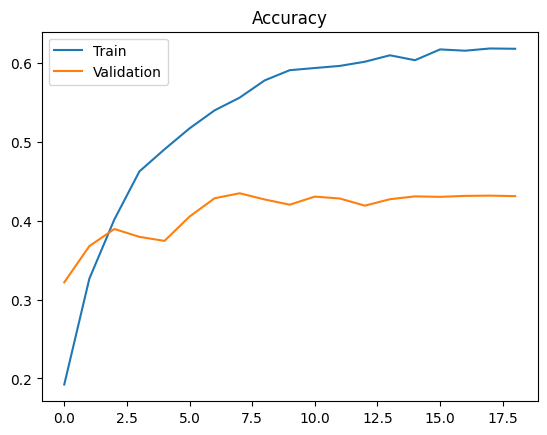

In [ ]:
# Accuracy curve
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title('Accuracy')
plt.show()

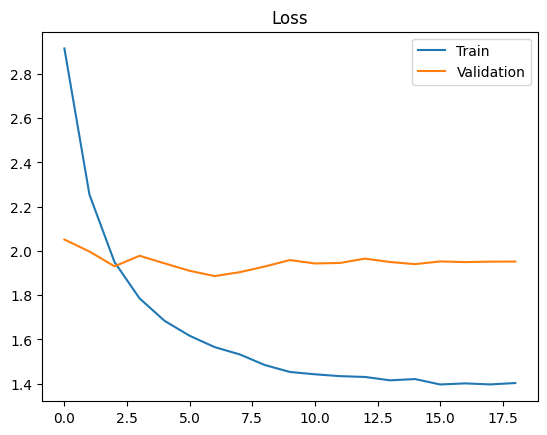

In [ ]:
# Loss curve
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title('Loss')
plt.show()

In [ ]:
import time
import numpy as np

sample_batch = next(iter(test_ds))[0]

start = time.time()
pred = model.predict(sample_batch)
end = time.time()

time_per_image = (end - start) / len(sample_batch)
print("Time per image (seconds):", time_per_image)
time_per_image = time_per_image * 1000
print("Time per image (milliseconds):", time_per_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Time per image (seconds): 0.15721634030342102
Time per image (milliseconds): 157.21634030342102


In [ ]:
base_model.trainable = True

# Freeze most layers, train last 80
for layer in base_model.layers[:-80]:
    layer.trainable = False

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 320, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 320, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 320, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 320, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 10, 10, 1280)   │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,765,024 (10.55 MB)

 Trainable params: 2,235,786 (8.53 MB)

 Non-trainable params: 193,088 (754.25 KB)

 Optimizer params: 336,150 (1.28 MB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "mobileNet_best_model.keras",
    monitor='val_loss',
    save_best_only=True
)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-6),  # lower LR
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/30
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 171s 90ms/step - accuracy: 0.3555 - loss: 1.9656 - val_accuracy: 0.4203 - val_loss: 1.8030 - learning_rate: 3.0000e-06
Epoch 2/30
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 193s 85ms/step - accuracy: 0.4322 - loss: 1.7387 - val_accuracy: 0.4384 - val_loss: 1.7120 - learning_rate: 3.0000e-06
Epoch 3/30
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 145s 85ms/step - accuracy: 0.5001 - loss: 1.5671 - val_accuracy: 0.4656 - val_loss: 1.6548 - learning_rate: 3.0000e-06
Epoch 4/30
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 207s 87ms/step - accuracy: 0.5566 - loss: 1.4198 - val_accuracy: 0.4967 - val_loss: 1.5793 - learning_rate: 3.0000e-06
Epoch 5/30
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 157s 92ms/step - accuracy: 0.5969 - loss: 1.3108 - val_accuracy: 0.5154 - val_loss: 1.5322 - learning_rate: 3.0000e-06
Epoch 6/30
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 151s 89ms/step - accuracy: 0.6376 - loss: 1.2270 - val_accuracy: 0.5317 - val_loss: 1.5010 - learning_rate: 3.0000e-06
Epoch 7/30
1680/1680 ━━━━━━━━━━━━━

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Driver-wise Test Accuracy:", test_acc)

709/709 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.6407 - loss: 1.2390
Driver-wise Test Accuracy: 0.6406911015510559


In [ ]:
model.save("/content/data/models/mobileNet80_imp2.keras")

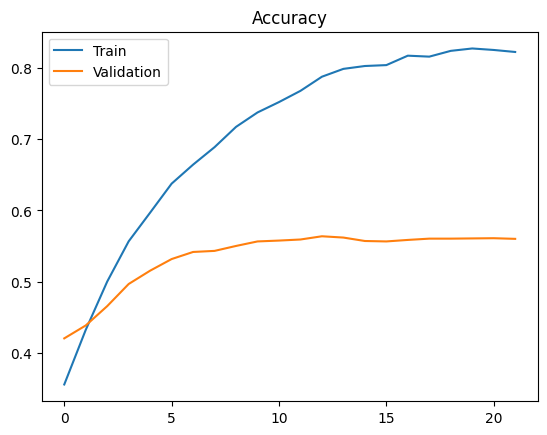

In [ ]:
# Accuracy curve
plt.plot(history_fine.history['accuracy'])
plt.plot(history_fine.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title('Accuracy')
plt.show()

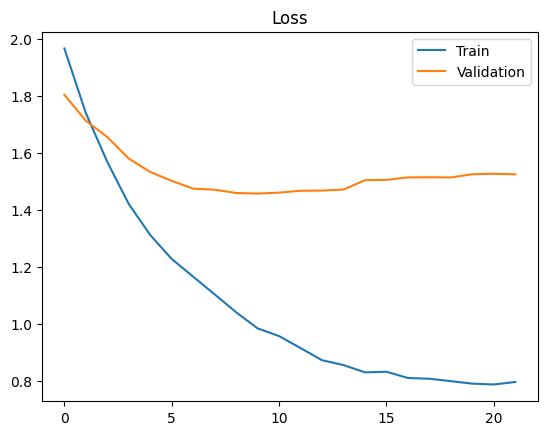

In [ ]:
# Loss curve
plt.plot(history_fine.history['loss'])
plt.plot(history_fine.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title('Loss')
plt.show()

In [ ]:
import time
import numpy as np

sample_batch = next(iter(test_ds))[0]

start = time.time()
pred = model.predict(sample_batch)
end = time.time()

time_per_image = (end - start) / len(sample_batch)
print("Time per image (seconds):", time_per_image)
time_per_image = time_per_image * 1000
print("Time per image (milliseconds):", time_per_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Time per image (seconds): 0.18045642971992493
Time per image (milliseconds): 180.45642971992493


**Using weighted decay**

In [ ]:
model.load_weights("mobileNet_best_model.keras")

In [ ]:
from tensorflow.keras.optimizers import AdamW

model.compile(
    optimizer=AdamW(
        learning_rate=3e-6,
        weight_decay=1e-5
    ),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

In [ ]:
history_fine_2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 177s 93ms/step - accuracy: 0.7613 - loss: 0.9345 - val_accuracy: 0.5553 - val_loss: 1.4790 - learning_rate: 3.0000e-06
Epoch 2/20
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 154s 91ms/step - accuracy: 0.7702 - loss: 0.9135 - val_accuracy: 0.5550 - val_loss: 1.4770 - learning_rate: 3.0000e-06
Epoch 3/20
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 149s 87ms/step - accuracy: 0.7865 - loss: 0.8792 - val_accuracy: 0.5571 - val_loss: 1.4661 - learning_rate: 3.0000e-06
Epoch 4/20
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 202s 87ms/step - accuracy: 0.7954 - loss: 0.8527 - val_accuracy: 0.5568 - val_loss: 1.4816 - learning_rate: 1.5000e-06
Epoch 5/20
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 209s 92ms/step - accuracy: 0.8047 - loss: 0.8328 - val_accuracy: 0.5586 - val_loss: 1.4834 - learning_rate: 1.5000e-06
Epoch 6/20
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 150s 88ms/step - accuracy: 0.8060 - loss: 0.8289 - val_accuracy: 0.5592 - val_loss: 1.4883 - learning_rate: 1.5000e-06
Epoch 7/20
1680/1680 ━━━━━━━━━━━━━

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Driver-wise Test Accuracy (AdamW):", test_acc)

709/709 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.6414 - loss: 1.2551
Driver-wise Test Accuracy (AdamW): 0.6413963437080383


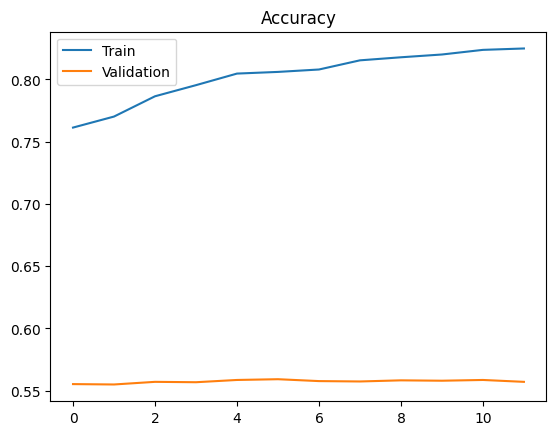

In [ ]:
# Accuracy curve
plt.plot(history_fine_2.history['accuracy'])
plt.plot(history_fine_2.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title('Accuracy')
plt.show()

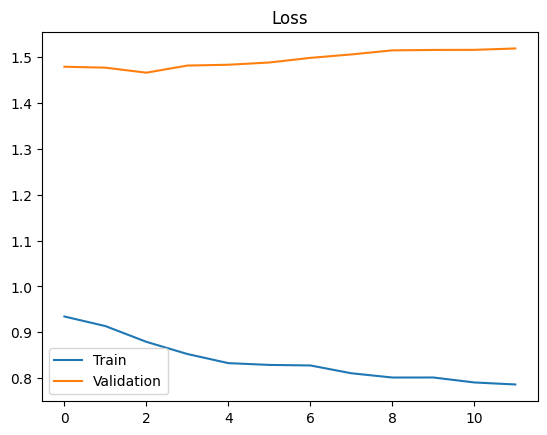

In [ ]:
# Loss curve
plt.plot(history_fine_2.history['loss'])
plt.plot(history_fine_2.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title('Loss')
plt.show()

In [ ]:
import time
import numpy as np

sample_batch = next(iter(test_ds))[0]

start = time.time()
pred = model.predict(sample_batch)
end = time.time()

time_per_image = (end - start) / len(sample_batch)
print("Time per image (seconds):", time_per_image)
time_per_image = time_per_image * 1000
print("Time per image (milliseconds):", time_per_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Time per image (seconds): 0.19211620092391968
Time per image (milliseconds): 192.11620092391968
